# To do 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Run the next 4 cells
# N points randomly drawn from a linear distribution
N = 100
X = 2 * np.random.rand(N, 1)
y = 4 + 3 * X + np.random.randn(N, 1)

# Turn X into a matrix
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each 

# Grid for plotting
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance

X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance

In [3]:
eta = 0.1  # learning rate
n_iterations = 100
theta = np.random.randn(2,1)  # random initialization

for iteration in range(n_iterations):
    gradients = 2/N * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [4]:
n_lines=10
color_idx = np.linspace(0, 1, n_lines)

# Helper function
theta_path_bgd = []
def plot_gradient_descent(theta, eta, theta_path=None):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_iterations = 1000
    
    for iteration in range(n_iterations):
        if iteration < 10:
            y_predict = X_new_b.dot(theta)
            plt.plot(X_new, y_predict, color=plt.cm.cool(color_idx[iteration]))
            
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if theta_path is not None:
            theta_path.append(theta)
            
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)

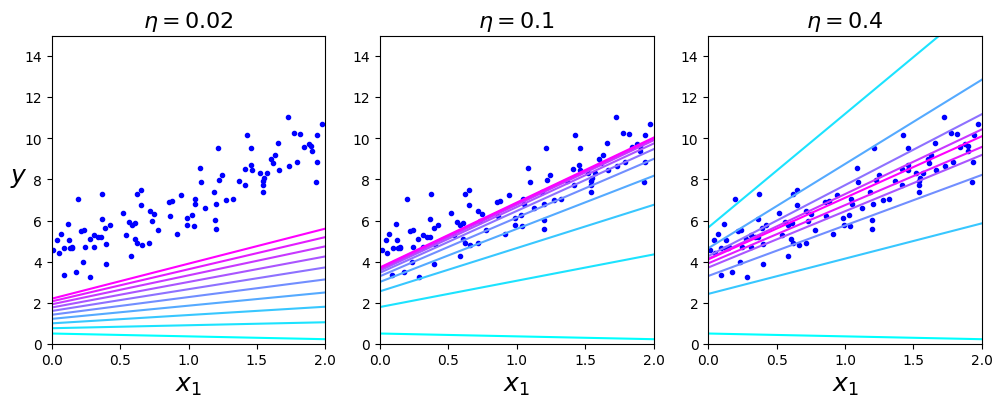

In [10]:
np.random.seed(42)
theta = np.random.randn(2,1)  # random initialization
plt.figure(figsize=(12,4))

plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)

plt.subplot(132); plot_gradient_descent(theta, eta=0.1, 
                                        theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.4)
plt.show()

# To do 2

In [11]:
# Run the next 3 cells
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [12]:
#Helper function for plotting
from matplotlib.colors import ListedColormap
def plot_decision_boundary(clf, X, y, 
                           axes=[-1.5, 2.45, -1, 1.5], 
                           alpha=0.5, contour=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha)
    
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

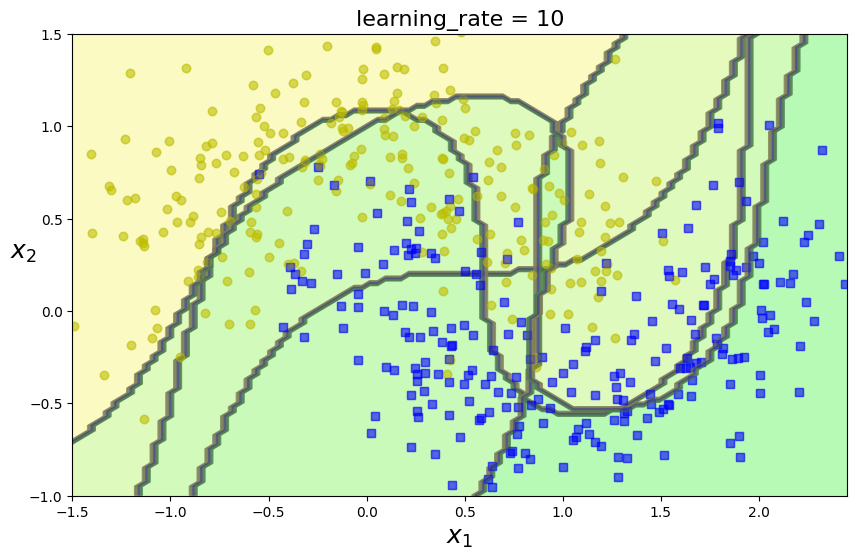

In [19]:
from sklearn.svm import SVC

learning_rate=10
m = len(X_train)

fix, axes = plt.subplots(ncols=1, figsize=(10,6))
sample_weights = np.ones(m)
for i in range(4):
    svm_clf = SVC(kernel="rbf", C=0.05, gamma="scale", random_state=42)
    svm_clf.fit(X_train, y_train, sample_weight=sample_weights)
    
    y_pred = svm_clf.predict(X_train)
    sample_weights[y_pred != y_train] *= (1 + learning_rate)
    
    plot_decision_boundary(svm_clf, X, y, alpha=0.2)
    plt.title("learning_rate = {}".format(learning_rate), fontsize=16)
